## Modelo *Sequence-to-Sequence* para Predicción Multipasos en Series de Tiempo

Un modelo *sequence-to-sequence* (Seq2Seq) consiste en dos redes neuronales recurrentes:
un **codificador (encoder)** y un **decodificador (decoder)**.
El objetivo es mapear una secuencia de entrada de valores temporales hacia una secuencia de predicciones futuras.

### Secuencias de Entrada y Salida

Sea la secuencia de entrada:

$$
\mathbf{x} = (x_1, x_2, \ldots, x_T)
$$

El modelo debe predecir los siguientes $H$ pasos:

$$
\mathbf{y} = (y_1, y_2, \ldots, y_K)
$$

donde $T$ es la longitud de la ventana observada y $K$ es el horizonte de predicción.

### Codificador (*Encoder*)

El codificador es una red recurrente (por ejemplo, RNN, LSTM, GRU) que lee la secuencia de entrada paso a paso y produce una secuencia de estados ocultos:

$$
H_t = f_{\theta}(x_t, H_{t-1}) = \phi( W_x x_t + W_H H_{t-1} + b_H )
$$

El estado oculto final resume toda la secuencia de entrada:

$$
H_T = \text{Encoder}(\mathbf{x})
$$

Este vector $H_T$ se conoce como **vector de contexto** o **representación latente**. 


<center><img src="https://d2l.ai/_images/rnn.svg"/></center>



[Referencia](https://d2l.ai/chapter_recurrent-modern/lstm.html)

## Decodificador (*Decoder*)

El decodificador es otra RNN que genera los valores futuros de manera autorregresiva.
Se inicializa con el estado final del codificador:

$$
S_0 = H_T
$$

En cada futuro paso temporal $\tau$, el decodificador usa su salida previa como entrada:

$$
S_{\tau} = g(y_{\tau-1}, S_{\tau-1}) = \phi( W_y y_{\tau} + W_S S_{\tau-1} + b_S )
$$

Normalmente, una capa *Dense* mapea $S_{\tau}$ al valor predicho:

$$
\hat{y_{\tau}} = W S_{\tau} + b
$$

### Objetivo de Entrenamiento

El modelo minimiza el error cuadrático medio (MSE) entre la secuencia predicha y la secuencia futura real:

$$
\mathcal{L}(\theta, \phi)
= \frac{1}{H} \sum_{\tau=1}^{H}
(y_{\tau} - \hat{y}_{\tau})^2
$$


In [ ]:

# Seq 2 seq --> forcasting multi step (ejemplo horizonte de tiempo)
# Seq 2 one 
# One 2 Seq

# Seq + Tab --> Multivariable


# Ejemplo

In [30]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

import matplotlib.pyplot as plt

## Hiperparametros

In [3]:
INPUT_LEN = 30
OUTPUT_LEN = 10
BATCH_SIZE = 64
HIDDEN_UNITS = 64
EPOCHS = 20
LR = 1e-3

## Datos sinteticos

In [4]:

def make_sine_dataset(n_series=800, series_len=400):
    xs = []
    for i in range(n_series):
        t = np.arange(series_len)
        s = np.sin(0.02 * t) + np.random.normal(0, 0.05, series_len)
        xs.append(s)
    return np.array(xs)

def make_windows(series_array, input_len, output_len, stride=1):
    X_enc, Y_dec = [], []
    for s in series_array:
        for start in range(0, len(s) - input_len - output_len + 1, stride):
            X_enc.append(s[start:start+input_len])
            Y_dec.append(s[start+input_len:start+input_len+output_len])
    return np.expand_dims(X_enc, -1), np.expand_dims(Y_dec, -1)

In [ ]:
# serie = [1,2,3,4,5,6,7,8]

# X = [1,2,3,4] - Y = [5,6]
# X = [2,3,4,5] - Y = [6,7]
# X = [3,4,5,6] - Y = [7,8]


## Encoder & Decoder

In [5]:

class Encoder(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.rnn = layers.SimpleRNN(units, return_state=True)

    def call(self, x):
        _, h = self.rnn(x)
        return h  

class Decoder(tf.keras.layers.Layer):
    def __init__(self, units, output_dim=1):
        super().__init__()
        self.cell = layers.SimpleRNNCell(units)
        self.rnn = layers.RNN(self.cell, return_sequences=True, return_state=True)
        self.dense = layers.Dense(output_dim)

    def call(self, x, initial_state):
        seq, h = self.rnn(x, initial_state=[initial_state])
        out = self.dense(seq)
        return out, h

## Modelo Seq2Seq

In [ ]:
[1,2,3,4] - [5,6]

[1,2,3,4] - 5
[2,3,4,5] - 6




In [6]:
class Seq2Seq(tf.keras.Model):
    def __init__(self, units):
        super().__init__()
        self.encoder = Encoder(units)
        self.decoder = Decoder(units)

    def call(self, encoder_inputs, decoder_inputs=None, training=False):
        h = self.encoder(encoder_inputs)

        if training:
            outputs, _ = self.decoder(decoder_inputs, initial_state=h)
            return outputs

        outputs = []
        last = tf.expand_dims(encoder_inputs[:, -1, :], 1)

        for t in range(OUTPUT_LEN):
            out, h = self.decoder(last, initial_state=h)
            outputs.append(out)
            last = out

        return tf.concat(outputs, axis=1)

In [7]:
series = make_sine_dataset()
series

array([[-0.01847195, -0.04311888,  0.17811424, ...,  0.97893405,
         1.00341865,  0.94458445],
       [-0.06016428, -0.06076229, -0.05111979, ...,  1.03209646,
         0.94976642,  1.01506255],
       [ 0.02065292,  0.02832417,  0.08593863, ...,  1.00422819,
         0.90046161,  0.99805015],
       ...,
       [-0.01594012,  0.02310355,  0.01941059, ...,  0.95326534,
         0.97605782,  1.00252726],
       [-0.12942329, -0.0100564 ,  0.04308565, ...,  1.08261206,
         0.98730153,  0.99873537],
       [ 0.0534067 ,  0.08132961,  0.06113179, ...,  1.02770797,
         0.99019532,  1.02112803]])

In [8]:
series.shape

(800, 400)

In [9]:
X, Y = make_windows(series, INPUT_LEN, OUTPUT_LEN, stride=3)

In [10]:
print(X.shape, Y.shape)

(96800, 30, 1) (96800, 10, 1)


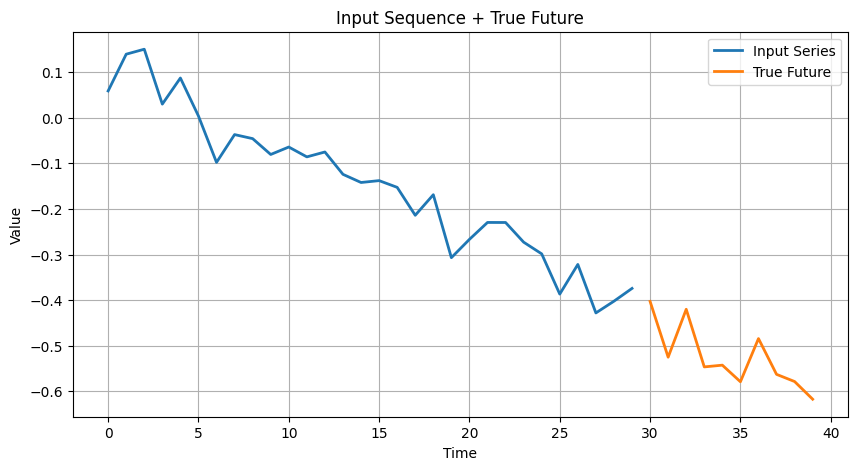

In [32]:
t = np.arange(100)

input_len = 30
output_len = 10

input_series = X[50]
true_future = Y[50]

plt.figure(figsize=(10, 5))
plt.plot(np.arange(input_len), input_series, label="Input Series", linewidth=2)
plt.plot(np.arange(input_len, input_len + output_len), true_future, label="True Future", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Input Sequence + True Future")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
split = int(len(X) * 0.8)
X_train, Y_train = X[:split], Y[:split]
X_val, Y_val = X[split:], Y[split:]

In [16]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(BATCH_SIZE)

I0000 00:00:1785882629.614121  464402 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12916 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


## Entrenamiento

In [17]:
model = Seq2Seq(HIDDEN_UNITS)
opt = tf.keras.optimizers.Adam(LR)
loss_fn = tf.keras.losses.MeanSquaredError()

In [18]:
@tf.function
def train_step(enc_inp, dec_target):
    start = tf.expand_dims(enc_inp[:, -1, :], 1)
    dec_inp = tf.concat([start, dec_target[:, :-1, :]], axis=1)

    with tf.GradientTape() as tape:
        preds = model(enc_inp, decoder_inputs=dec_inp, training=True)
        loss = loss_fn(dec_target, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))
    return loss

In [19]:
for epoch in range(EPOCHS):
    t_losses = []
    for xb, yb in train_ds:
        t_losses.append(train_step(xb, yb).numpy())

    v_losses = []
    for xb, yb in val_ds:
        preds = model(xb, training=False)
        v_losses.append(loss_fn(yb, preds).numpy())

    print(f"Epoch {epoch+1} - train: {np.mean(t_losses):.4f}  val: {np.mean(v_losses):.4f}")

2026-08-04 16:31:00.356022: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-04 16:31:32.139303: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1 - train: 0.0058  val: 0.0038


2026-08-04 16:32:30.201252: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2 - train: 0.0029  val: 0.0031
Epoch 3 - train: 0.0029  val: 0.0032


2026-08-04 16:34:27.356872: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 4 - train: 0.0029  val: 0.0031
Epoch 5 - train: 0.0029  val: 0.0029
Epoch 6 - train: 0.0028  val: 0.0029
Epoch 7 - train: 0.0028  val: 0.0029


2026-08-04 16:38:19.337417: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 8 - train: 0.0028  val: 0.0028
Epoch 9 - train: 0.0028  val: 0.0028
Epoch 10 - train: 0.0028  val: 0.0029
Epoch 11 - train: 0.0028  val: 0.0029
Epoch 12 - train: 0.0028  val: 0.0029
Epoch 13 - train: 0.0028  val: 0.0030
Epoch 14 - train: 0.0027  val: 0.0030
Epoch 15 - train: 0.0028  val: 0.0030


2026-08-04 16:46:10.831894: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 16 - train: 0.0027  val: 0.0029
Epoch 17 - train: 0.0027  val: 0.0028
Epoch 18 - train: 0.0027  val: 0.0028
Epoch 19 - train: 0.0027  val: 0.0028
Epoch 20 - train: 0.0027  val: 0.0028


In [20]:
model.summary()

Model: "seq2_seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │         4,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,513 (33.25 KB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
pred_future

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[0.9258707 ],
       [0.9408702 ],
       [0.9527084 ],
       [0.95153755],
       [0.9602095 ],
       [0.9686663 ],
       [0.9675265 ],
       [0.9756989 ],
       [0.981296  ],
       [0.98322934]], dtype=float32)>

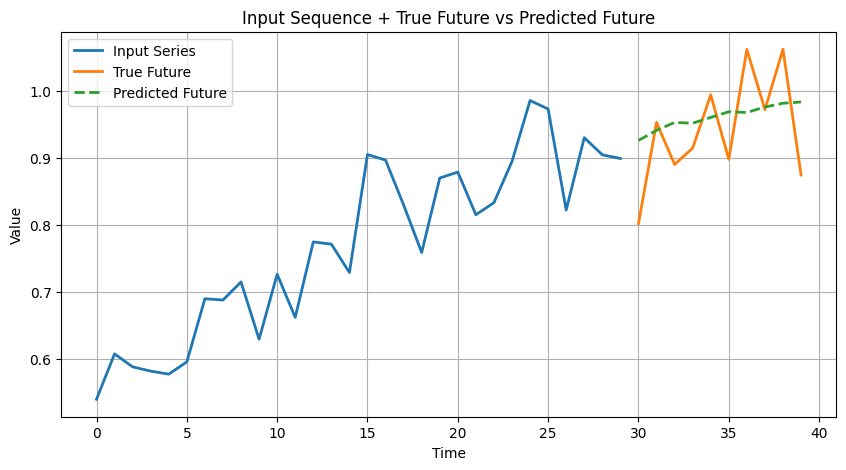

In [21]:
t = np.arange(100)
# series = np.sin(0.1 * t)

input_len = 30
output_len = 10

input_series = X_val[10]
true_future = Y_val[10]
pred_future = model(np.array([input_series]))[0]

plt.figure(figsize=(10, 5))
plt.plot(np.arange(input_len), input_series, label="Input Series", linewidth=2)
plt.plot(np.arange(input_len, input_len + output_len), true_future, label="True Future", linewidth=2)
plt.plot(np.arange(input_len, input_len + output_len), pred_future, label="Predicted Future", linestyle="--", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Input Sequence + True Future vs Predicted Future")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
pred_future

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[0.9258707 ],
       [0.9408702 ],
       [0.9527084 ],
       [0.95153755],
       [0.9602095 ],
       [0.9686663 ],
       [0.9675265 ],
       [0.9756989 ],
       [0.981296  ],
       [0.98322934]], dtype=float32)>

# Modelo

In [23]:
model.layers

[<Encoder name=encoder, built=True>, <Decoder name=decoder, built=True>]

In [24]:
encoder = model.layers[0]
decoder = model.layers[1]

In [25]:
emb = encoder(X_val)
emb.shape

TensorShape([19360, 64])

In [26]:
X_val.shape

(19360, 30, 1)

In [28]:
# input: serie_ventas=[1,12,2,1,1,2,532,5] ---> RNN (Encoder) --> vector H
# inputs: [campañas, feriados, etc] ---> Dense NN ---> 

# concatenar: [output_rnn, input_tabular] ---> RNN --> 

# output: [2,5,6,4,5]

In [29]:
2*2

4